### 【[K線捕手](https://www.facebook.com/kevinyang20180801)盤前快訊】高檔反壓，短線震盪  
昨天盤前提到「補漲行情，留意反壓」，加權指數如規劃的開盤大漲202點，但幾乎是很有節奏的，隨即一步一步出現瑕疵。首先以上周表現，其實攻高只要2500-2600億的量就夠了，但今天開盤預估量一次衝到4000億(收盤仍高達3756億)。  
在關鍵壓力區爆量，難免有些疑慮，雖然要持續向上挑戰攻高，本來就要補量，只是一次性量太大，又到壓力區，一旦爆量就只能前進不能後退，否則容易有解套賣壓和高檔出貨的風險。  
其次，盤前也提醒「20日線附近可能就會有升值壓力」，原先強勢反彈的台幣也出現止升回貶的現象，未來台幣將進入狹幅整理。再者是期貨率先走弱，出現中長黑K棒，緊接著櫃買指數由AI族群領跌一路走低，個股高低差甚至高達10%以上。  
最後還是結構的問題，表面加權指數收漲151點，但貢獻指數漲點主要來自台積電和金融股，並非雨露均霑，且根據上市櫃上總計，上漲檔數佔1/3，但下跌檔數卻佔了2/3，如果再納入上漲但開高走低的個股，這樣實質上漲的可能只有1/4。
這意味著一般人隨機選股勝率只剩下2以左右，如果再加上多空趨勢的條件，恐怕剩下1成不到，這就是為什麼盤前說指數雖然會上漲，但非常考驗選股功力。  
雖然多方有瑕疵，但至少16400站穩，籌碼也有改善，算是對多方稍有加分。最近的走勢真的像是在考試，單日漲跌變化多，選股難度也高，再來由於到季線和下降壓力線，約在16750的複合壓力區，國際股市也都同步到反彈壓力區，不易連續攻高，盤勢又會開始震盪。 (出處：K線捕手楊忠憲粉絲團)  
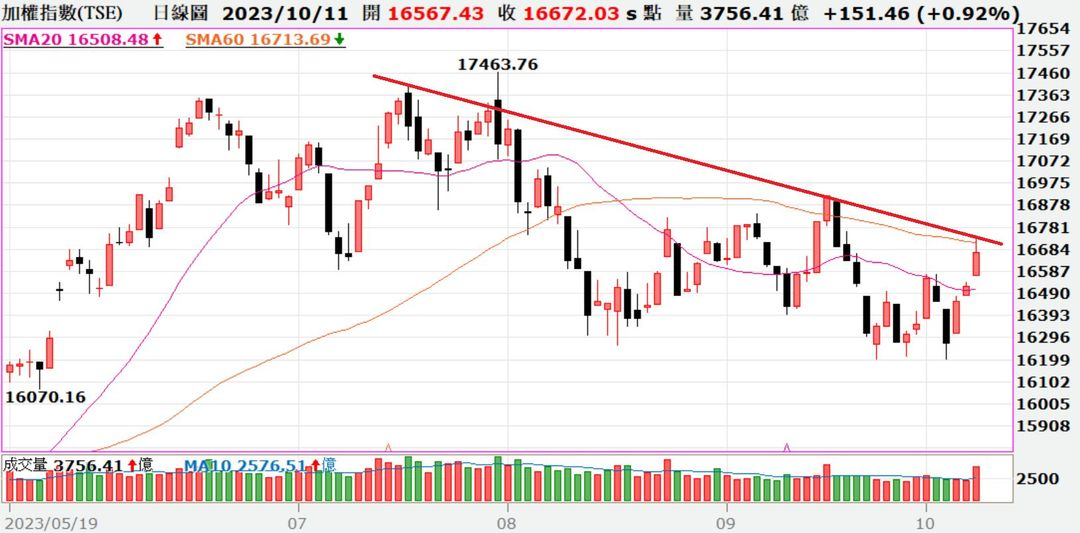

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np

In [2]:
##### 使用2023年5月19日到今天收盤(2023年10月12日)的日K線資料繪製 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_TSE_231012.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10', 'DIF12-26','MACD9','OSC','K(9,3)','D(9,3)'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10', 'DIF12-26','MACD9','OSC','K(9,3)','D(9,3)']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

In [3]:
def date_to_index(df_in,date_in) :
    number_array = df_in.index == date_in
    idx = 0
    for number_index in number_array :
        if number_index == True :
            break
        idx = idx + 1
    return idx

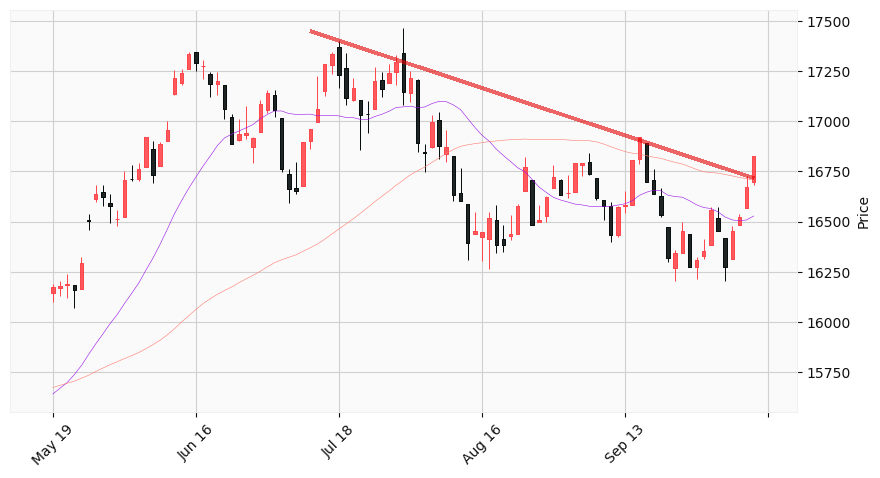

In [4]:
# 設定下降趨勢線
resistance_line_x_date = ['2023-07-18','2023-09-18']
resistance_line_x = [date_to_index(df_k_line,resistance_line_x_date[0]),date_to_index(df_k_line,resistance_line_x_date[1])]
resistance_line_y = [df_k_line.loc[resistance_line_x_date[0]]['High'],df_k_line.loc[resistance_line_x_date[1]]['High']]
slope,intercept = np.polyfit(resistance_line_x,resistance_line_y,1)
resistance_line_start_date = '2023-07-12'
resistance_line_start_price = slope * date_to_index(df_k_line,resistance_line_start_date) + intercept
resistance_line_end_date = '2023-10-12'
resistance_line_end_price = slope * date_to_index(df_k_line,resistance_line_end_date) + intercept

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(resistance_line_start_date,resistance_line_start_price),(resistance_line_end_date,resistance_line_end_price)]
                     ]

# 設定均線
added_plots={
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=0.4,color='xkcd:violet'),
    "SMA60": mpf.make_addplot(df_sma['SMA60'],width=0.4,color='xkcd:salmon')
            }

# 繪製K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=list(added_plots.values()), alines=dict(alines=seq_of_seq_of_points, linewidths=2, colors='xkcd:red', alpha=0.6))
mpf.plot(df_k_line,**kwargs)

[9月出口終結12黑](https://readers.ctee.com.tw/cm/20231012/a01aa1/1262400/share)  
  
[美9月PPI增速 高於預期](https://readers.ctee.com.tw/cm/20231012/a01aa1/1262403/share)  
  
[聯發科Q3營收 站上1,100億](https://readers.ctee.com.tw/cm/20231012/a03aa3/1262411/share)  
  
[油價漲 台塑四寶Q3獲利飆](https://readers.ctee.com.tw/cm/20231012/a04aa4/1262417/share)  
  
[績優前十強吸金 年底行情擂鼓](https://readers.ctee.com.tw/cm/20231012/a45aaa1/1262576/share)  

日本續漲，暫時站上箱型中軸之上：  
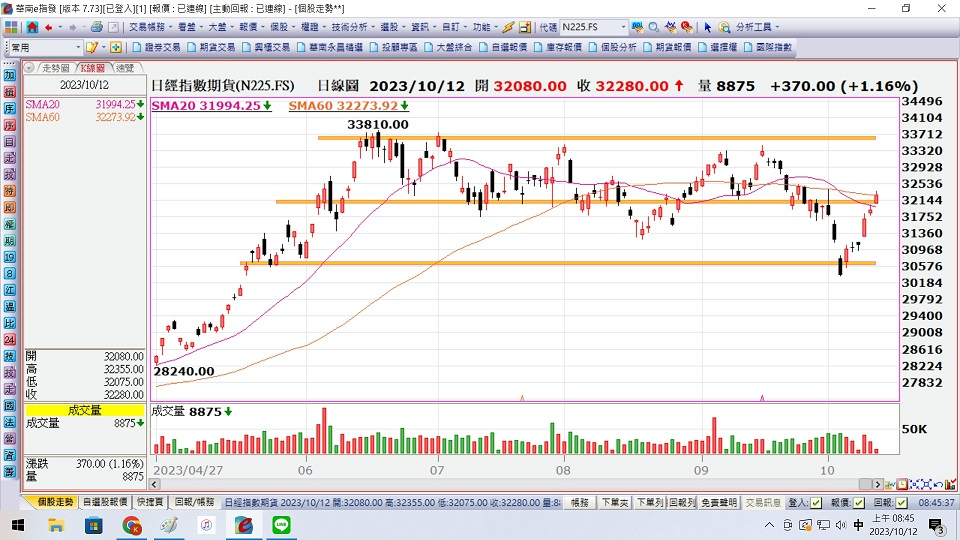  
  
期貨小漲，尚未過昨天高點：  
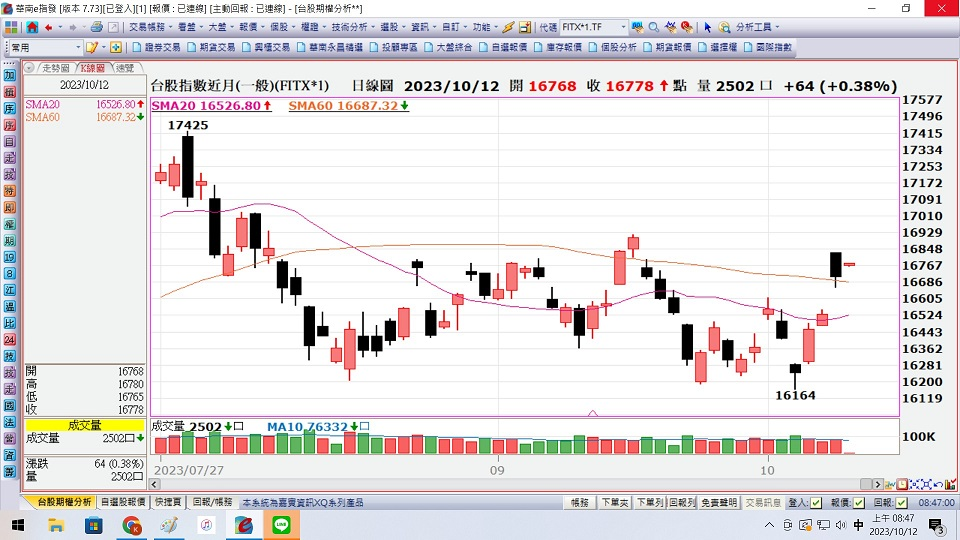  
  
加權指數小漲，尚未突破關鍵壓力：  
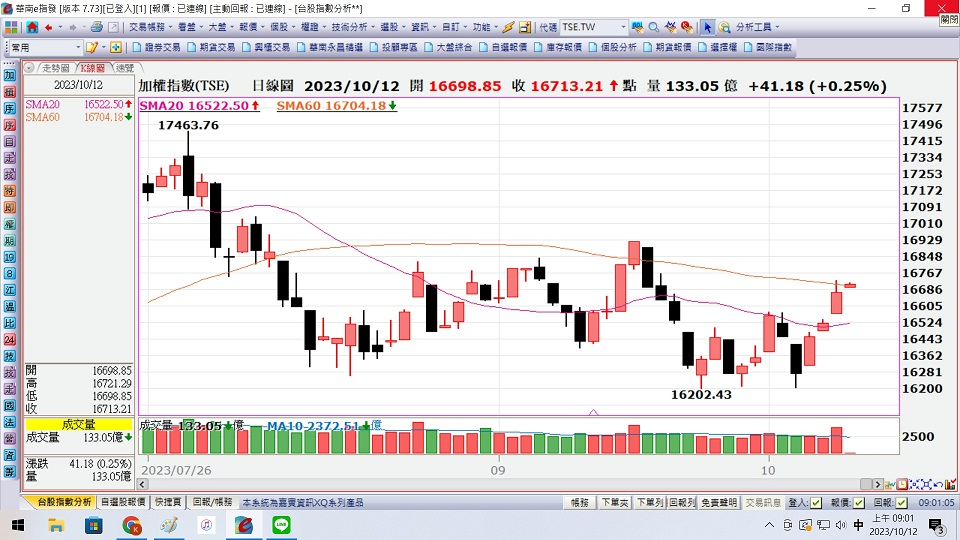  
  
櫃買指數小漲，尚未突破下降壓力線：  
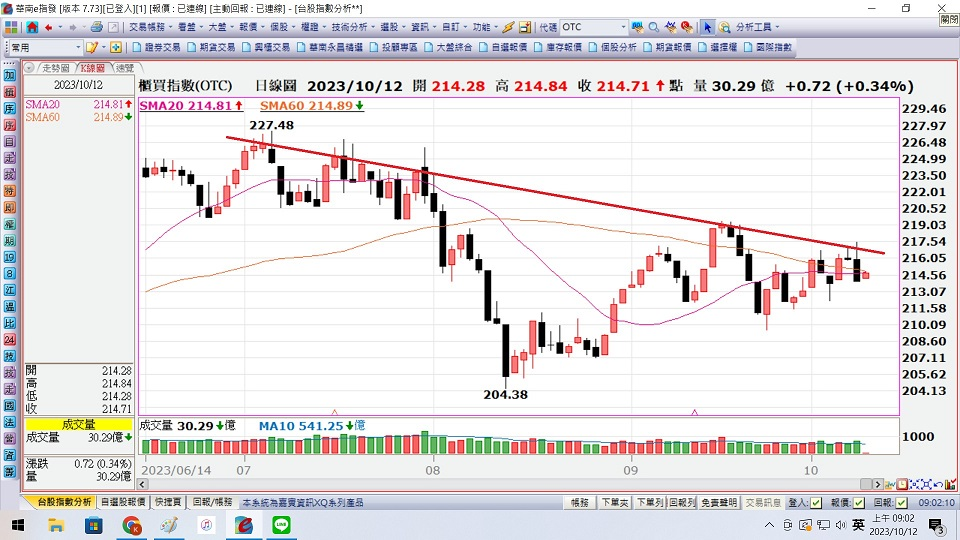  

友輝(4933)  
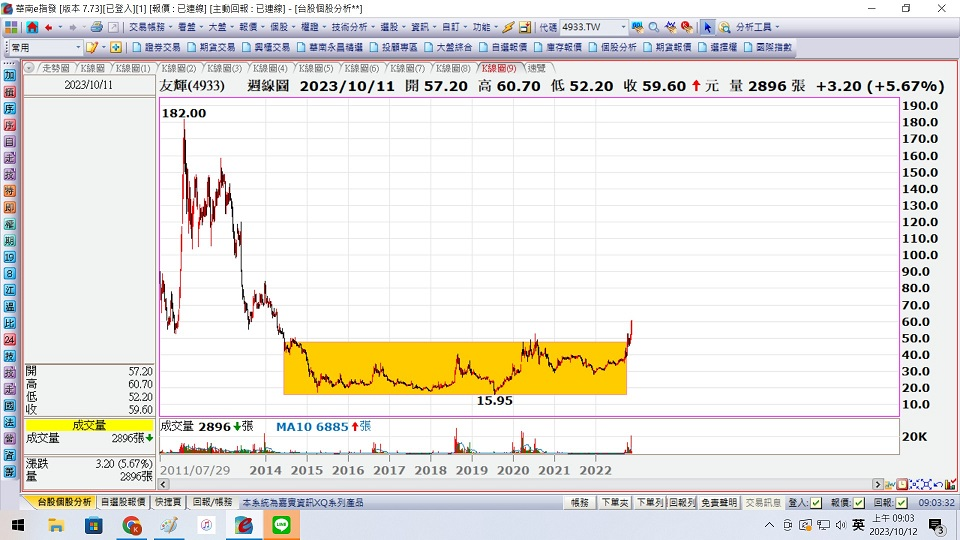  
  
矽統(2363)  
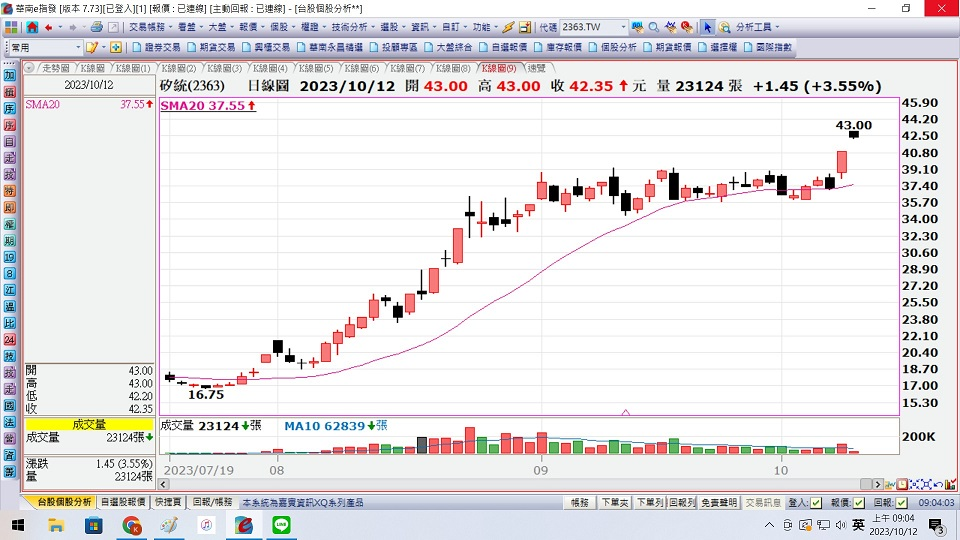  
  
麗臺(2465)  
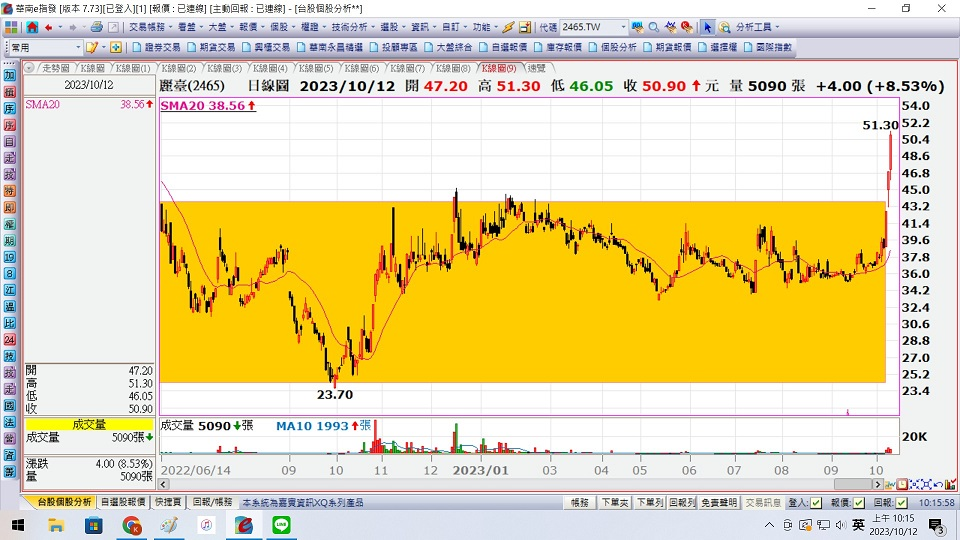

今天指數漲幅收斂，但讓市場稍微冷靜一下是好事，畢竟反壓仍多，不要急著攻高

【[其實我也沒有全程在電腦前盯盤](https://www.facebook.com/kevinyang20180801/posts/pfbid0FzYjzREfzgF31Q9P4ZEa3C1w9WcAcFPUWKmT4LzPMpnc9Hr5XRgrq21uJStDHUN5l)】  
有些同學覺得不能在電腦前全程盯盤，好像就不利於做股票，但其實並不是這樣，雖然能在電腦前全程看盤是真的比較幸福，因為資訊很完整，比較不會錯失細節，尤其如果操作期貨、權證、選擇權、股期或是極短線交易，當然最好要能用電腦盯盤，但如果是交易現股，其實不需要這麼緊繃。  
我常說買賣股票有不只有一天，怎麼會因為盤中買賣點錯過，就無法交易呢？還有第二天、第三天…，當然能全程盯盤有其的優點，尤其在關鍵轉折日可以買賣的較為精確，但是相對盯太緊也有缺點，有時候盤中假突破、假跌破時反而會過度敏感，還不如收盤前再確認，甚至我自己本身也不是從頭看到尾，只有重點的時候看一下。  
但是電腦版跟手機版的使用，是真的有差異，手機版因為載具介面的先天限制，基本上像是玩具，有其不足之處，所以我都會建議上班族回家一定要完整的用電腦版檢視一遍，短中長週期、趨勢、位階、型態、籌碼…，把想要買進賣出的個股，關鍵的支撐、壓力、停利、停損位置設定出來，可以寫成簡易小抄或筆記備用，那白天就留意這些重點即可。  
你錯過第一步棋，永遠有下一步棋可以走的，突破第一天沒買到，第二天可以擬訂追買策略，第二天沒買到可以擬訂拉回的時候再動作，已經漲上去、漲太多了，你還有下一檔股票可以買。總之，不能全程盯盤或是不能用電腦版軟體看盤，不會是你賺賠的原因，而是事前事後的功課，有沒有做紮實。  

港股持續反彈，但已經很接近壓力區：  
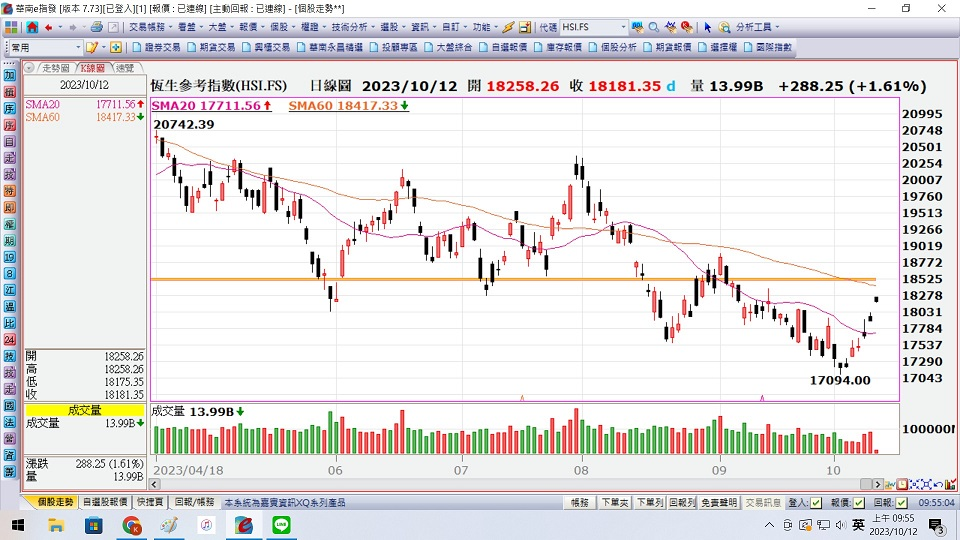  
  
陸股漲幅相對小，弱勢盤整格局：  
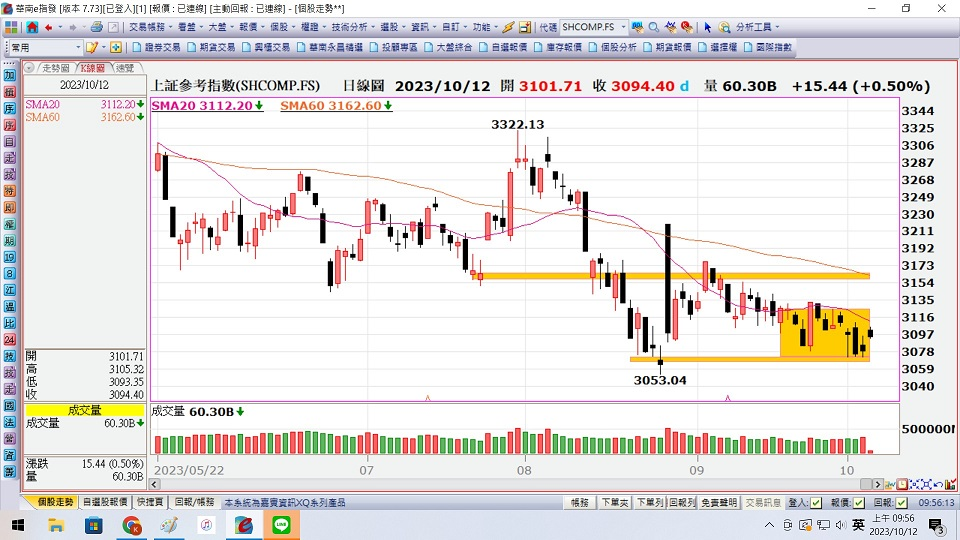  
  
單就這個指標而言，加權指數有機會來挑戰前高：  
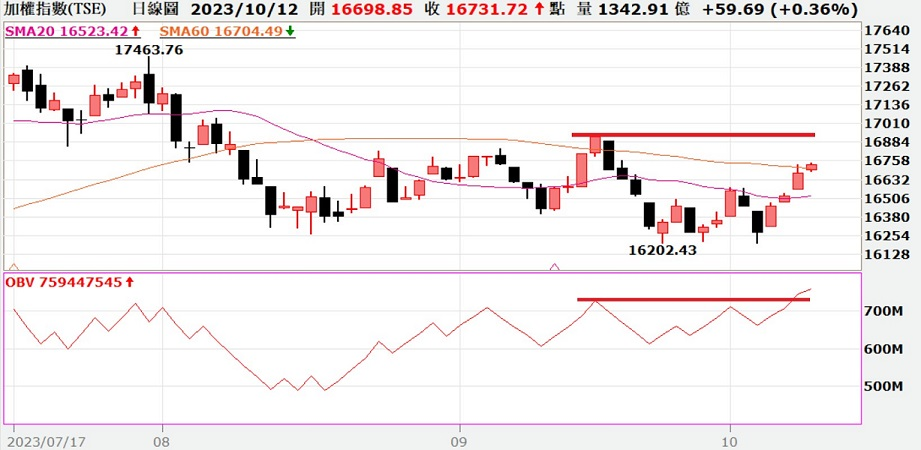  
  
今天漲幅相對昨天小，但比較健康，加權和櫃買一起漲：  
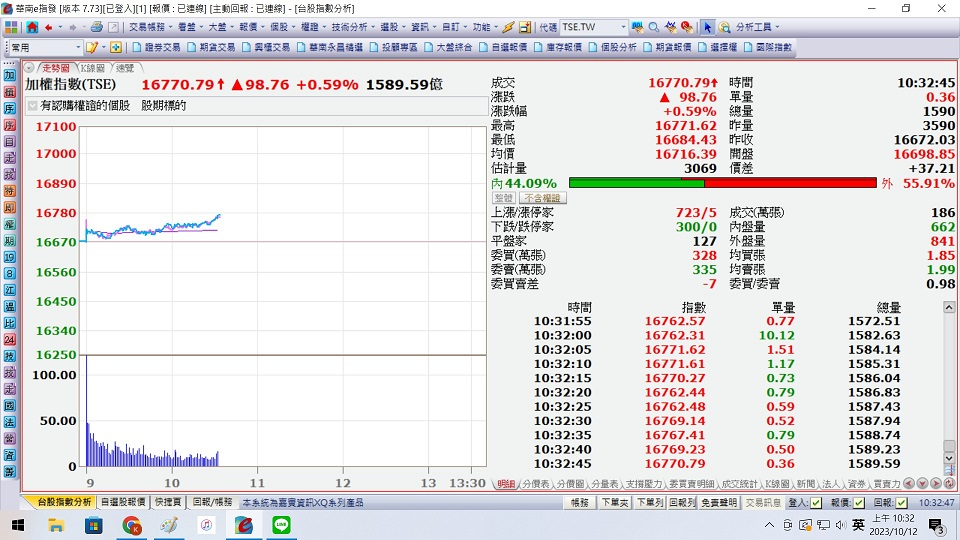  
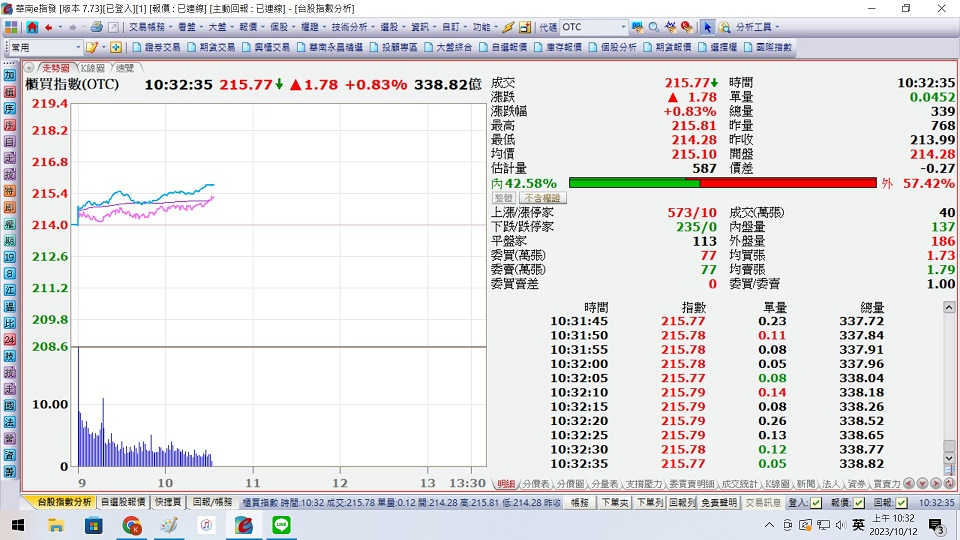  
  
16750上下震盪：  
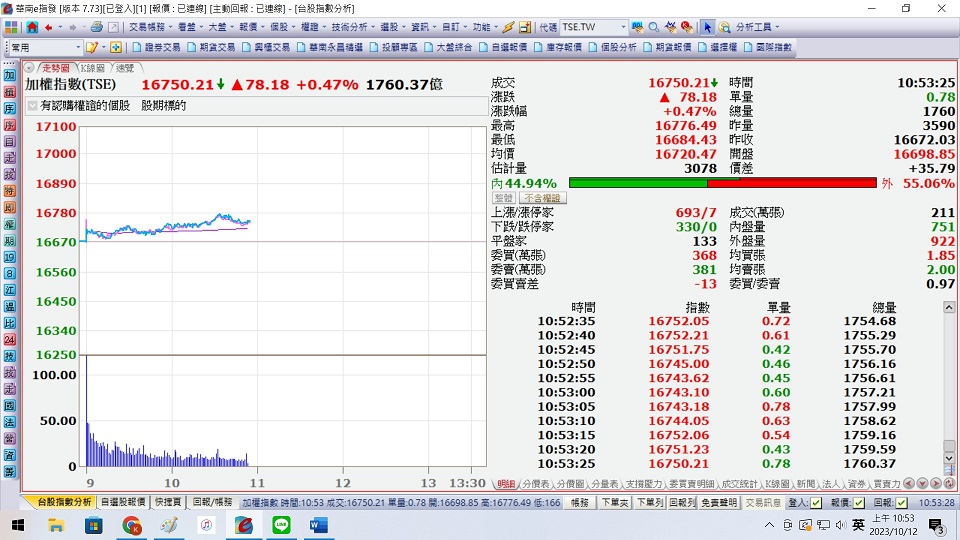  

【指數強弱分析程序】  
  
1.初步-單日指數漲跌與量能關係  
2.內涵-單日上漲與下跌家數  
3.圖形-指數的趨勢、型態、位階  
4.結構-類股多空結構  
5.外在-國際股市多空強弱  

分析指數的程序，如果這四關都過，表示指數是真的轉強了，有興趣可以自己存檔，不過目前還沒符合。  

今天的漲跌比例，明顯比昨天健康許多。  
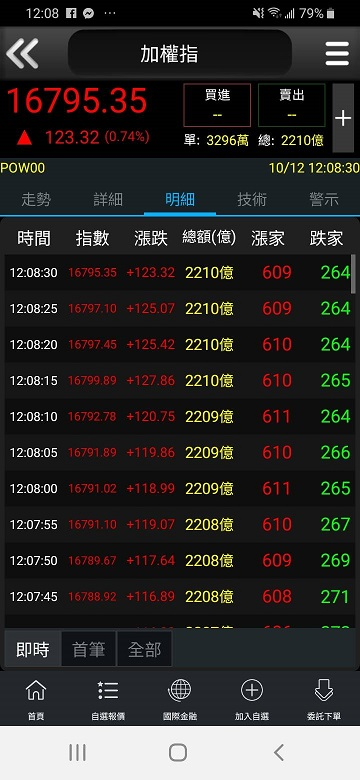  
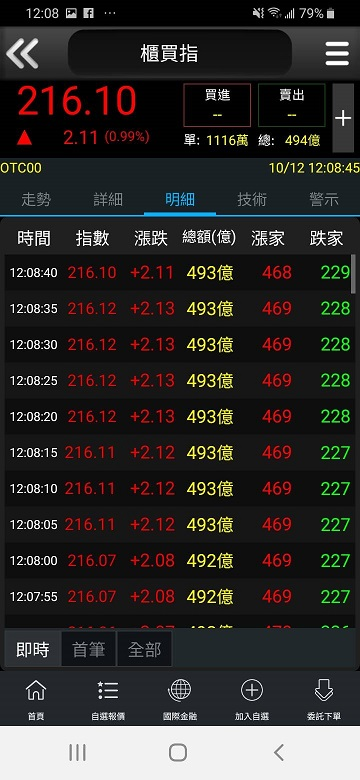  

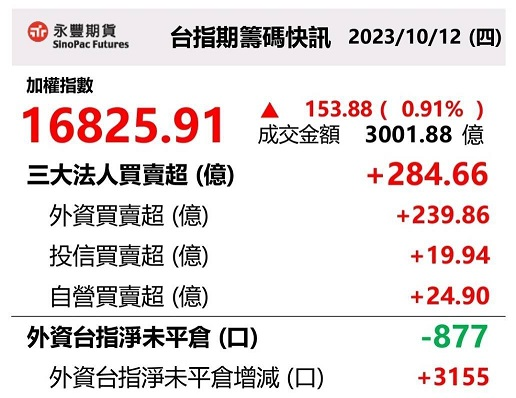  
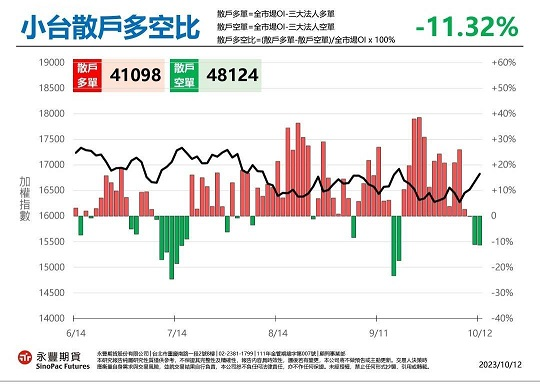  

#### 【K線捕手楊忠憲技術/籌碼概況說明】
以下不是我的持股，也不是推 薦，是網友主動提問，由於都是我自己逐字整理，不是用電腦程式或是軟體機器人，但提問數量眾多，礙於時間跟版面，無法詳答和附圖，只能簡略回答個股現況。  
相關內容依照技術面和籌碼面做整理，僅為個人看法，完全開放無償分享，不做為任何交易之依據。任何投資都有風險，請審慎評估資金狀況、投資目標、風險承受程度及獨立交易的能力，並善設停利停損。  
  
3036文曄  強勢多頭，但位階高，要會設移動支撐  
3707漢磊  短中長期都偏空，支撐不穩  
6806森威能源  短線反彈後的盤整，中期大箱型整理  
8930青鋼  有高檔轉弱現象，籌碼不強  
3008大立光  短線盤整，中期大箱型整理  
8016矽創  高檔轉弱，有迷你頭部雛形  
2206三陽工業  中期狹幅整理，籌碼不強  
1319東陽  強勢多頭，但位階高，要會設移動支撐  
6223旺矽  高檔盤整，籌碼不強  
8996高力  短線轉強，中期箱型區間  
4533協易機  有頭部現象，弱勢盤整  
6189豐藝  多頭高檔震盪，後續暫不明朗  
5285界霖  短線轉弱，有中期頭部雛形  
2105正新  中長期底形，緩漲，籌碼集中  
6684安格  中長期底形，緩漲，籌碼中性  
6789采鈺  低檔盤整，籌碼不強  
2476鉅祥  有中期底部雛形，籌碼集中，但尚未轉強  
6274台燿  短線高檔轉弱，中期盤整，籌碼轉弱中  
1513中興電  高檔轉弱後的狹幅盤整，趨勢不明朗  
2465麗臺  中長期底形，急漲，籌碼集中  
5269祥碩  中期反彈到前高，後續暫不明朗  
6282康舒  中期頭部現象，籌碼偏空  
  
#### 【K線捕手楊忠憲技術/籌碼概況說明】  
以下不是我的持股，也不是推 薦，是網友主動提問，由於都是我自己逐字整理，不是用電腦程式或是軟體機器人，但提問數量眾多，礙於時間跟版面，無法詳答和附圖，只能簡略回答個股現況。  
相關內容依照技術面和籌碼面做整理，僅為個人看法，完全開放無償分享，不做為任何交易之依據。任何投資都有風險，請審慎評估資金狀況、投資目標、風險承受程度及獨立交易的能力，並善設停利停損。  
  
2454聯發科  短線偏多籌碼集中，但往上反壓也不小，空間暫不明朗  
2330台積電  短線轉強，中期回到大箱型區間，近日籌碼集中  
8050廣積  有中期頭部現象，籌碼偏空  
3558神準  弱勢盤整支撐不穩，籌碼不強  
4933友輝  長期底形，籌碼集中，緩漲中  
1722台肥  短線反彈，後續不明朗  
6202盛群  短中長期偏空，支撐不穩  
6245立端  中長期頭部雛形，籌碼偏空  
1707葡萄王  有中長期頭部現象，籌碼偏空，支撐不穩  
2385群光  強勢多頭，但位階高，要會設移動支撐  
1815富喬  底形漲幅滿足，短線轉弱  

### 本日進度  
* **暫時空手**，觀察後續盤勢發展。  